## TASK B

In this task, you will be processing the following datasets:

- Clusters-4.csv  
- Clusters-5.csv
- Clusters-6.csv  

1. Divide each data set into ‘train’ and ‘test’ datasets, once, and use them for all subsequent steps.

2. Use the following algorithms / variants to process the datasets:

   a. Logistic Regression  
   b. Logistic Regression after adding polynomial features  
   c. SVC - with ‘linear’ kernel (what is ‘linear’?)  
   d. SVC - with ‘rbf’ kernel (what is ‘rbf’?)  
   e. Random Forest Classifier - for various combinations of “minimum observations per leaf” (say 1 to 5) and “tree depth” (say 2 to 5). Think of this as a “grid search” problem, where a model is created for every combination of these parameters.  
   f. K-Nearest Neighbours - Try different values of k (e.g., 1, 3, 5, 7, 9) and observe how it affects overfitting vs smoothing.  
   g. Neural Network Classifier - with hidden_layer_sizes = (4)  
   h. Neural Network Classifier - with hidden_layer_sizes = (4, 4)  
   i. Neural Network Classifier - with hidden_layer_sizes = (4, 4, 4)  
   j. Neural Network Classifier - with hidden_layer_sizes = (8)  

3. In each of the above cases, generate, capture, and save all the metrics for all the datasets into a common CSV file to facilitate analysis later on. The following metrics (for train and test data) should be created:

   a. Accuracy, Precision (per class), Precision (average), Recall (per class), Recall (average), F1-score (per class), F1-score (average), AUC (per class), AUC (average)  

   b. (Hint: The following functions may be used: accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve)

In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, label_binarize
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# -----------------------------
# Metrics Function
# -----------------------------
def compute_metrics(model, X_train, X_test, y_train, y_test, model_name, dataset_name):

    results = []

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_train_prob = model.predict_proba(X_train)
        y_test_prob = model.predict_proba(X_test)
    else:
        y_train_prob = None
        y_test_prob = None

    classes = np.unique(y_train)

    for split, y_true, y_pred, y_prob in [
        ("train", y_train, y_train_pred, y_train_prob),
        ("test", y_test, y_test_pred, y_test_prob)
    ]:

        precision_pc = precision_score(y_true, y_pred, labels=classes, average=None, zero_division=0)
        recall_pc = recall_score(y_true, y_pred, labels=classes, average=None, zero_division=0)
        f1_pc = f1_score(y_true, y_pred, labels=classes, average=None, zero_division=0)

        acc = accuracy_score(y_true, y_pred)

        precision_avg = np.mean(precision_pc)
        recall_avg = np.mean(recall_pc)
        f1_avg = np.mean(f1_pc)

        auc_pc = [None] * len(classes)
        auc_avg = None

        if y_prob is not None:
            try:
                y_bin = label_binarize(y_true, classes=classes)

                if len(classes) > 1:
                    auc_vals = roc_auc_score(
                        y_bin,
                        y_prob,
                        average=None,
                        multi_class='ovr'
                    )

                    auc_pc = auc_vals
                    auc_avg = np.mean(auc_vals)

            except:
                pass

        row = {
            "dataset": dataset_name,
            "model": model_name,
            "split": split,
            "accuracy": acc,
            "precision_avg": precision_avg,
            "recall_avg": recall_avg,
            "f1_avg": f1_avg,
            "auc_avg": auc_avg
        }

        for i, cls in enumerate(classes):
            row[f"precision_{cls}"] = precision_pc[i]
            row[f"recall_{cls}"] = recall_pc[i]
            row[f"f1_{cls}"] = f1_pc[i]
            row[f"auc_{cls}"] = auc_pc[i] if auc_pc[i] is not None else None

        results.append(row)

    return results


# -----------------------------
# MAIN EXECUTION
# -----------------------------
datasets = [
    "data/clusters-4.csv",
    "data/clusters-5.csv",
    "data/clusters-6.csv"
]

# Excel writer
writer = pd.ExcelWriter("model_metrics.xlsx", engine='openpyxl')

for file in datasets:

    print(f"\nProcessing {file}...")

    data = pd.read_csv(file)

    X = data.iloc[:, :-1]
    y = data.iloc[:, -1]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    all_results = []

    # -----------------------------
    # Models
    # -----------------------------
    models = {

        "Logistic": LogisticRegression(max_iter=500),

        "Logistic_Poly": Pipeline([
            ('poly', PolynomialFeatures(degree=2)),
            ('scaler', StandardScaler()),
            ('logreg', LogisticRegression(max_iter=500))
        ]),

        "SVC_Linear": SVC(kernel='linear', probability=True),

        "SVC_RBF": SVC(kernel='rbf', probability=True),

        "NN_(4)": MLPClassifier(hidden_layer_sizes=(4,), max_iter=500, early_stopping=True),

        "NN_(4,4)": MLPClassifier(hidden_layer_sizes=(4,4), max_iter=500, early_stopping=True),

        "NN_(4,4,4)": MLPClassifier(hidden_layer_sizes=(4,4,4), max_iter=500, early_stopping=True),

        "NN_(8)": MLPClassifier(hidden_layer_sizes=(8,), max_iter=500, early_stopping=True),
    }

    # -----------------------------
    # Standard Models
    # -----------------------------
    for name, model in models.items():

        if "Poly" in name:
            model.fit(X_train, y_train)
            results = compute_metrics(model, X_train, X_test, y_train, y_test, name, file)
        else:
            model.fit(X_train_scaled, y_train)
            results = compute_metrics(model, X_train_scaled, X_test_scaled, y_train, y_test, name, file)

        all_results.extend(results)

    # -----------------------------
    # Random Forest Grid Search
    # -----------------------------
    for leaf in range(1, 6):
        for depth in range(2, 6):

            model = RandomForestClassifier(
                min_samples_leaf=leaf,
                max_depth=depth,
                random_state=42
            )

            model.fit(X_train, y_train)

            name = f"RF_leaf{leaf}_depth{depth}"

            results = compute_metrics(model, X_train, X_test, y_train, y_test, name, file)
            all_results.extend(results)

    # -----------------------------
    # KNN Variations
    # -----------------------------
    for k in [1, 3, 5, 7, 9]:

        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train_scaled, y_train)

        name = f"KNN_k{k}"

        results = compute_metrics(model, X_train_scaled, X_test_scaled, y_train, y_test, name, file)
        all_results.extend(results)

    # -----------------------------
    # Create DataFrame
    # -----------------------------
    df = pd.DataFrame(all_results)

    classes = sorted(np.unique(y))

    ordered_cols = (
        ["dataset", "model", "split", "accuracy"] +
        [f"precision_{i}" for i in classes] + ["precision_avg"] +
        [f"recall_{i}" for i in classes] + ["recall_avg"] +
        [f"f1_{i}" for i in classes] + ["f1_avg"] +
        [f"auc_{i}" for i in classes] + ["auc_avg"]
    )

    df = df[ordered_cols]

    # Sheet name
    sheet_name = file.split("/")[-1].replace(".csv", "")

    df.to_excel(writer, sheet_name=sheet_name, index=False)

# Save Excel
writer.close()

print("\n✅ Excel file created: model_metrics.xlsx (3 sheets)")


Processing data/clusters-4.csv...

Processing data/clusters-5.csv...

Processing data/clusters-6.csv...

✅ Excel file created: model_metrics.xlsx (3 sheets)


4. For each dataset, generate plots like the ones below - to understand the classification 
boundaries and the overall performance of the classifier:

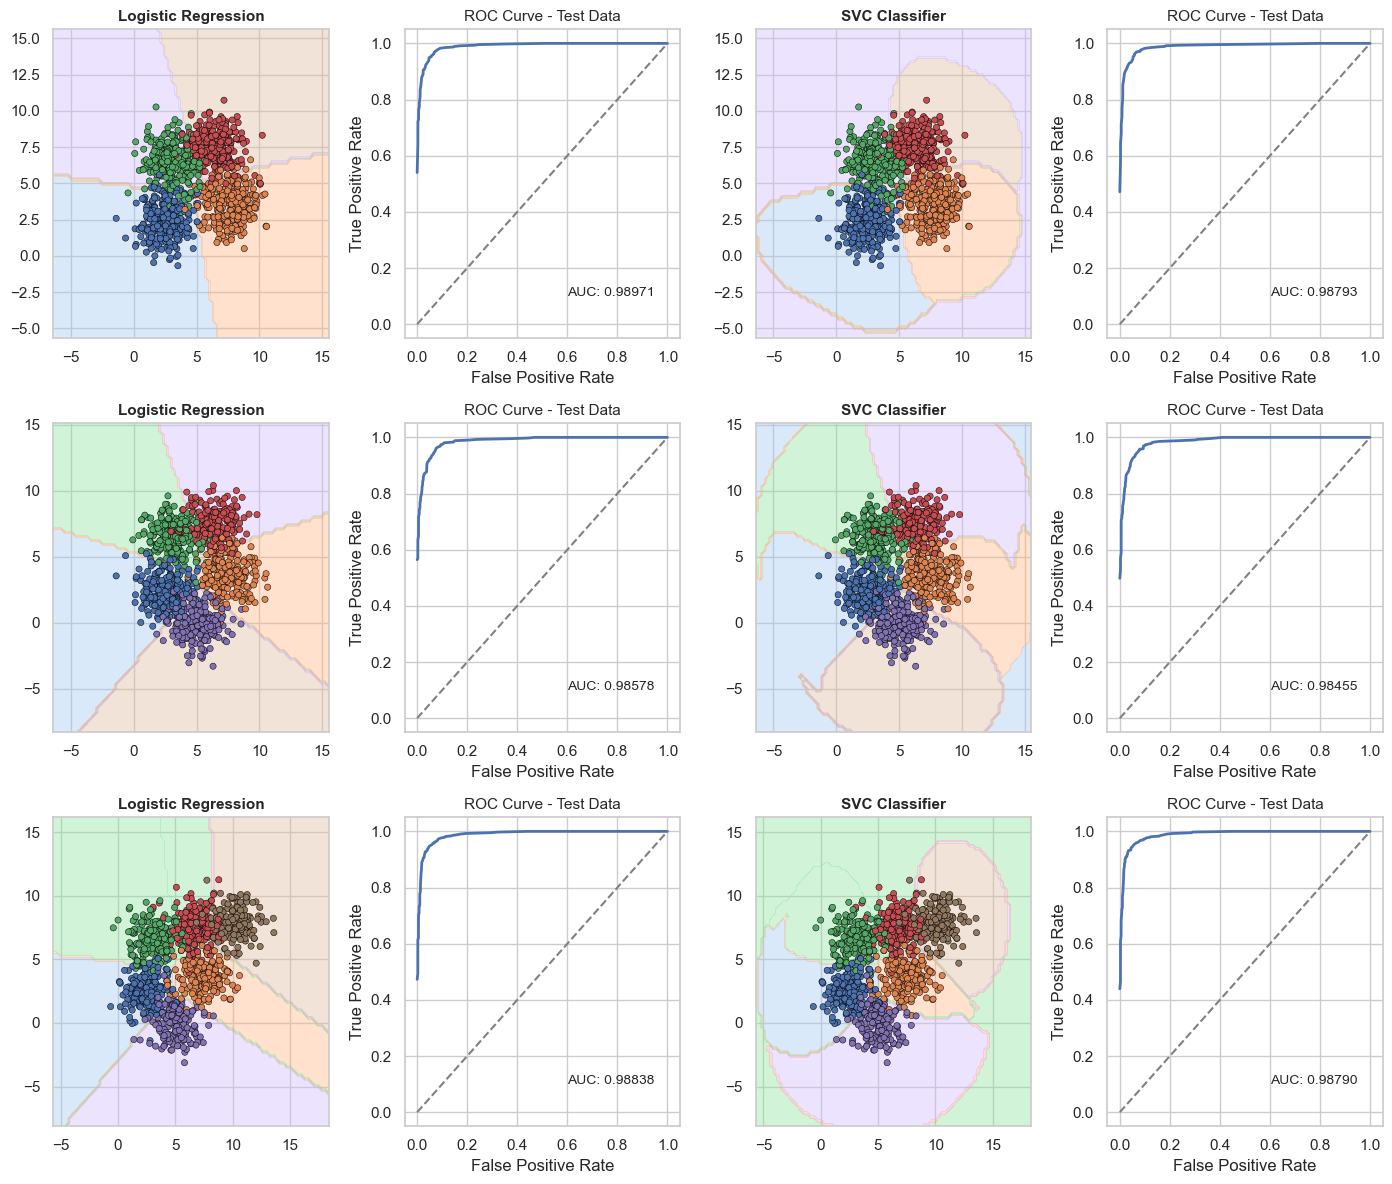

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc
from matplotlib.colors import ListedColormap

# -----------------------------
# STYLE
# -----------------------------
sns.set(style="whitegrid", context="notebook")

# -----------------------------
# DATASETS
# -----------------------------
datasets = [
    "data/clusters-4.csv",
    "data/clusters-5.csv",
    "data/clusters-6.csv"
]

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "SVC Classifier": SVC(kernel='rbf', probability=True)
}

# -----------------------------
# DECISION BOUNDARY FUNCTION
# -----------------------------
def plot_decision_boundary(ax, model, scaler, X_raw, y):

    h = 0.3
    x_min, x_max = X_raw[:, 0].min() - 5, X_raw[:, 0].max() + 5
    y_min, y_max = X_raw[:, 1].min() - 5, X_raw[:, 1].max() + 5

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    # Scale grid before prediction
    grid_scaled = scaler.transform(grid)

    Z = model.predict(grid_scaled)
    Z = Z.reshape(xx.shape)

    cmap_light = ListedColormap(sns.color_palette("pastel", 6))

    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_light)

    sns.scatterplot(
        x=X_raw[:, 0],
        y=X_raw[:, 1],
        hue=y,
        palette="deep",
        edgecolor="black",
        s=20,
        ax=ax,
        legend=False
    )

    ax.set_xlabel("")
    ax.set_ylabel("")


# -----------------------------
# ROC FUNCTION (SINGLE CURVE)
# -----------------------------
def plot_roc(ax, model, X_test, y_test):

    if not hasattr(model, "predict_proba"):
        ax.set_title("ROC not available")
        return

    y_prob = model.predict_proba(X_test)
    classes = np.unique(y_test)

    y_bin = label_binarize(y_test, classes=classes)

    fpr = dict()
    tpr = dict()

    for i in range(len(classes)):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_prob[:, i])

    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classes))]))

    mean_tpr = np.zeros_like(all_fpr)

    for i in range(len(classes)):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= len(classes)

    roc_auc = auc(all_fpr, mean_tpr)

    ax.plot(all_fpr, mean_tpr, linewidth=2)
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")

    ax.text(0.6, 0.1, f"AUC: {roc_auc:.5f}", fontsize=10)


# -----------------------------
# MAIN PLOTTING
# -----------------------------
fig, axes = plt.subplots(len(datasets), len(models)*2, figsize=(14, 12))

for row, file in enumerate(datasets):

    data = pd.read_csv(file)

    # ONLY first 2 features for visualization
    X = data.iloc[:, :2].values
    y = data.iloc[:, -1].values

    # Split RAW data
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    # Scale ONLY for training
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    for col, (name, model) in enumerate(models.items()):

        # Train model
        model.fit(X_train_scaled, y_train)

        # -----------------------------
        # Decision Boundary
        # -----------------------------
        ax1 = axes[row, col*2]
        plot_decision_boundary(ax1, model, scaler, X_train_raw, y_train)
        ax1.set_title(name, fontsize=11, weight='bold')

        # -----------------------------
        # ROC Curve
        # -----------------------------
        ax2 = axes[row, col*2 + 1]
        plot_roc(ax2, model, X_test_scaled, y_test)
        ax2.set_title("ROC Curve - Test Data", fontsize=11)

# Layout
plt.tight_layout()
plt.show()

5. Compare the metrics within and across the datasets (train and test) and algorithms. In 
addition to the variations in metrics, compare aspects related to classification 
boundaries, overfitting, etc.

<div style="font-size: 12px;">
📊 Comparative Analysis of Models Across Datasets

## 1. Overview

Three datasets were analyzed:
- Clusters-4 (4 classes)
- Clusters-5 (5 classes)
- Clusters-6 (6 classes)

As the number of clusters increases, the classification problem becomes more complex due to:
- Increased class overlap
- More decision boundaries
- Higher chances of misclassification

---

## 2. Comparison Across Algorithms

### 🟢 Logistic Regression
- **Nature:** Linear classifier  
- **Performance:**
  - Performs well on simpler datasets (Clusters-4)
  - Performance slightly degrades as clusters increase  
- **Decision Boundary:**
  - Straight-line (linear separation)  
- **Observation:**
  - Cannot capture complex, non-linear cluster shapes  

---

### 🔵 SVC (RBF Kernel)
- **Nature:** Non-linear classifier  
- **Performance:**
  - Consistently high accuracy and AUC across all datasets  
  - Handles increasing clusters better than Logistic Regression  
- **Decision Boundary:**
  - Smooth, curved boundaries  
- **Observation:**
  - Better separation in overlapping regions  

---

### 🌳 Random Forest
- **Nature:** Ensemble of decision trees  
- **Performance:**
  - Very high training accuracy (often near 1.0)  
  - Slight drop in test accuracy  
- **Decision Boundary:**
  - Highly irregular and flexible  
- **Observation:**
  - Tends to **overfit**, especially with deeper trees  

---

### 🟡 K-Nearest Neighbours (KNN)
- **Nature:** Instance-based learning  
- **Performance:**
  - Small k (e.g., 1): very high training accuracy, lower test accuracy → overfitting  
  - Larger k (e.g., 7, 9): smoother decision boundary, better generalization  
- **Decision Boundary:**
  - Highly sensitive to k  
- **Observation:**
  - Trade-off between overfitting and smoothing  

---

### 🔴 Neural Networks
- **Nature:** Flexible non-linear models  
- **Performance:**
  - Improves with more layers (up to a point)  
  - Moderate generalization  
- **Decision Boundary:**
  - Complex, non-linear surfaces  
- **Observation:**
  - Can overfit if too complex  
  - Requires proper tuning  

---

## 3. Train vs Test Performance (Overfitting Analysis)

| Model | Train Accuracy | Test Accuracy | Interpretation |
|------|--------------|--------------|----------------|
| Logistic Regression | Moderate | Slightly lower | Good generalization |
| SVC (RBF) | High | High | Best balance |
| Random Forest | Very High (≈1.0) | Lower | Overfitting |
| KNN (k=1) | Very High | Lower | Overfitting |
| KNN (k=7,9) | Lower | Stable | Better generalization |
| Neural Networks | High | Slightly lower | Mild overfitting |

---

## 4. Effect of Increasing Clusters

| Dataset | Observation |
|--------|------------|
| Clusters-4 | Clear separation, high accuracy |
| Clusters-5 | Slight overlap, moderate drop in metrics |
| Clusters-6 | More overlap, harder classification |

### Key Trend:
- Accuracy decreases as number of clusters increases  
- AUC remains relatively high → models still rank classes well  

---

## 5. Decision Boundary Insights

### Linear vs Non-linear Models

| Model | Boundary Type | Performance |
|------|--------------|------------|
| Logistic Regression | Linear | Limited |
| SVC (RBF) | Non-linear | Strong |
| Random Forest | Highly irregular | Overfits |
| KNN | Data-dependent | Sensitive to k |
| Neural Network | Smooth non-linear | Flexible |

---

## 6. AUC Observations

- Most models achieve **high AUC (>0.95)**  
- Indicates:
  - Strong class separability  
  - Good ranking capability  

Even when accuracy drops slightly:  
AUC remains stable → model still effective  

---

## 7. Key Takeaways

- **Best overall model:** SVC (RBF Kernel)  
  - Handles non-linearity well  
  - Maintains strong train-test balance  

- **Most overfitting model:** Random Forest (deep trees)  
- **Most sensitive model:** KNN (depends heavily on k)  
- **Simplest but limited:** Logistic Regression  

---

## 8. Conclusion

- Increasing clusters increases classification complexity  
- Non-linear models outperform linear models  
- Overfitting is observed in flexible models (RF, low-k KNN)  
- SVC with RBF kernel provides the best trade-off between bias and variance
</div>